# 🌧️ STREAM-Sat Ensemble Precipitation Visualization

**Region:** Caribbean  |  **Members:** 50  |  **Resolution:** 0.5°, 30-min timesteps  |  **Period:** 2025-05-01 03:00 – 2025-05-03 02:30 UTC

This notebook provides interactive and static visualizations of the STREAM-Sat real-time ensemble QPE (Quantitative Precipitation Estimate). The ensemble captures uncertainty in satellite-derived precipitation estimates using perturbed motion vectors.

### Visualization sections:
1. **Ensemble Mean & Spread** — Map of ensemble mean + standard deviation
2. **Interactive Timestep Explorer** — Widget-based exploration with member overlay
3. **Percentile Maps** — 10th, 50th, 90th percentiles
4. **Probability of Exceedance** — P(prcp > threshold) maps
5. **Spaghetti Time Series** — All 50 members at selected grid points
6. **Accumulated Precipitation** — Ensemble mean accumulation over the period
7. **Hovmöller Diagram** — Time-longitude cross-section
8. **Animation** — Animated ensemble mean over time


In [1]:
# ═══════════════════════════════════════════
# 1. Imports
# ═══════════════════════════════════════════
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import ipywidgets as widgets
from IPython.display import display, HTML
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful")
print(f"   xarray v{xr.__version__}, numpy v{np.__version__}")
print(f"   matplotlib v{plt.matplotlib.__version__}, cartopy v{plt.matplotlib.__version__}")

✅ All imports successful
   xarray v2026.4.0, numpy v2.4.4
   matplotlib v3.10.9, cartopy v3.10.9


In [2]:
# ═══════════════════════════════════════════
# 2. Load Data — open all NetCDF files with xarray
# ═══════════════════════════════════════════
DATA_DIR = r'X:\WMO_Caribbean_Comoros\TITO\STREAM-Sat-realtime\extension\realtime\extension\realtime\output\caribbean'

# Use open_mfdataset to load all files as a single dataset
# Each file has shape (ens_n=50, time=1, lat=120, lon=370)
# xarray will concatenate along the 'time' dimension
ds = xr.open_mfdataset(
    f'{DATA_DIR}/STREAMSat_caribbean_*.nc',
    combine='nested',
    concat_dim='time',
    decode_times=True,
    chunks={'time': 24}  # chunk to avoid loading everything at once
)

# Sort by time
ds = ds.sortby('time')

print(f"✅ Loaded {len(ds.time)} timesteps, {ds.dims['ens_n']} ensemble members")
print(f"   Grid: {ds.dims['lat']} lat × {ds.dims['lon']} lon ({ds.lat.values[0]:.1f}° to {ds.lat.values[-1]:.1f}°N, "
      f"{ds.lon.values[0]:.1f}° to {ds.lon.values[-1]:.1f}°E)")
print(f"   Time range: {ds.time.values[0]} to {ds.time.values[-1]}")
print(f"   Variable 'prcp': {ds.prcp.shape}, units: {ds.prcp.units}")

✅ Loaded 96 timesteps, 50 ensemble members
   Grid: 120 lat × 370 lon (22.9° to 11.1°N, -93.9° to -57.0°E)
   Time range: 2025-05-01T03:00:00.000000000 to 2025-05-03T02:30:00.000000000
   Variable 'prcp': (50, 96, 120, 370), units: mm/hr


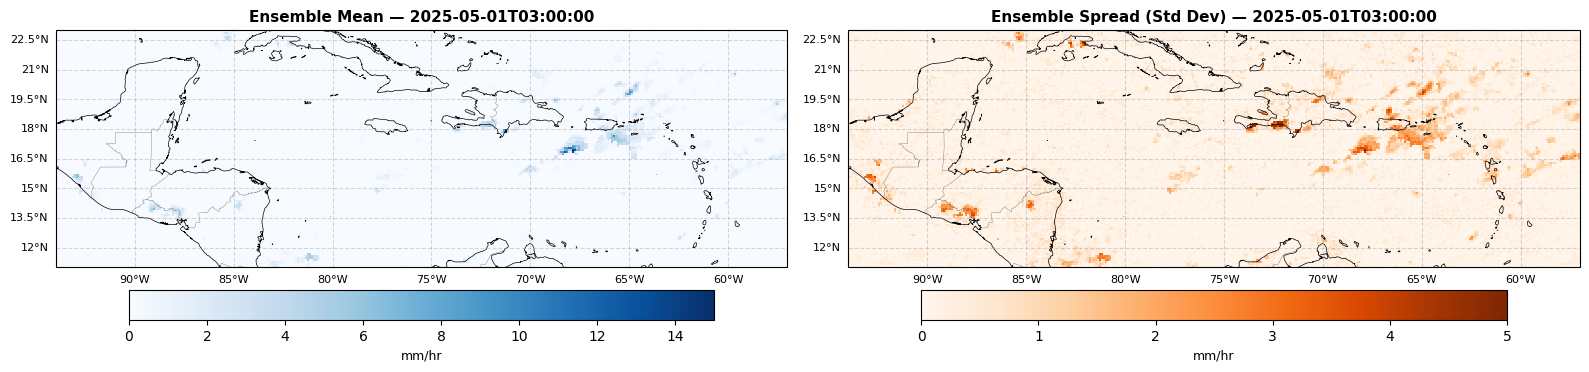

In [3]:
# ═══════════════════════════════════════════
# 3. Helper: Plotting function for ensemble maps
# ═══════════════════════════════════════════
def plot_ensemble_map(da, time_idx=0, member=None, ax=None, title=None,
                      vmin=0, vmax=20, cmap='Blues', cbar_label='mm/hr'):
    """Plot precipitation map for a given timestep. If member is None, plot ensemble mean."""
    prcp_data = da.isel(time=time_idx)
    if member is None:
        data = prcp_data.mean(dim='ens_n').values
        default_title = f'Ensemble Mean — {str(da.time.values[time_idx])[:19]}'
    else:
        data = prcp_data.isel(ens_n=member).values
        default_title = f'Member {member} — {str(da.time.values[time_idx])[:19]}'

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

    title = title or default_title

    pcm = ax.pcolormesh(da.lon.values, da.lat.values, data,
                        cmap=cmap, vmin=vmin, vmax=vmax,
                        transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    ax.add_feature(cfeature.OCEAN, color='lightgray', alpha=0.3)
    ax.add_feature(cfeature.LAKES, color='lightgray', alpha=0.3)
    ax.add_feature(cfeature.RIVERS, linewidth=0.3, alpha=0.5)

    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3, color='gray')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    cb = plt.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cb.set_label(cbar_label, fontsize=9)

    ax.set_title(title, fontsize=11, fontweight='bold')
    return fig

def plot_ensemble_mean_and_spread(da, time_idx=0, vmax_mean=15, vmax_spread=5):
    """Side-by-side ensemble mean and spread (std dev) maps."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5),
                                    subplot_kw={'projection': ccrs.PlateCarree()})

    prcp = da.isel(time=time_idx)
    ens_mean = prcp.mean(dim='ens_n').values
    ens_std = prcp.std(dim='ens_n').values
    t_str = str(da.time.values[time_idx])[:19]

    # Mean
    pcm1 = ax1.pcolormesh(da.lon.values, da.lat.values, ens_mean,
                          cmap='Blues', vmin=0, vmax=vmax_mean,
                          transform=ccrs.PlateCarree())
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax1.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    ax1.add_feature(cfeature.OCEAN, color='lightgray', alpha=0.3)
    gl1 = ax1.gridlines(draw_labels=True, linestyle='--', alpha=0.3, color='gray')
    gl1.top_labels = False; gl1.right_labels = False
    gl1.xformatter = LongitudeFormatter(); gl1.yformatter = LatitudeFormatter()
    gl1.xlabel_style = {'size': 8}; gl1.ylabel_style = {'size': 8}
    cb1 = plt.colorbar(pcm1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.8)
    cb1.set_label('mm/hr', fontsize=9)
    ax1.set_title(f'Ensemble Mean — {t_str}', fontsize=11, fontweight='bold')

    # Spread (std dev)
    pcm2 = ax2.pcolormesh(da.lon.values, da.lat.values, ens_std,
                          cmap='Oranges', vmin=0, vmax=vmax_spread,
                          transform=ccrs.PlateCarree())
    ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax2.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    ax2.add_feature(cfeature.OCEAN, color='lightgray', alpha=0.3)
    gl2 = ax2.gridlines(draw_labels=True, linestyle='--', alpha=0.3, color='gray')
    gl2.top_labels = False; gl2.right_labels = False
    gl2.xformatter = LongitudeFormatter(); gl2.yformatter = LatitudeFormatter()
    gl2.xlabel_style = {'size': 8}; gl2.ylabel_style = {'size': 8}
    cb2 = plt.colorbar(pcm2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.8)
    cb2.set_label('mm/hr', fontsize=9)
    ax2.set_title(f'Ensemble Spread (Std Dev) — {t_str}', fontsize=11, fontweight='bold')

    plt.tight_layout()
    return fig

# Quick test — first timestep
fig = plot_ensemble_mean_and_spread(ds.prcp, time_idx=0)
plt.show()

In [4]:
# ═══════════════════════════════════════════
# 4. Interactive Timestep Explorer (ipywidgets)
# ═══════════════════════════════════════════
# Use a slider to pick a timestep, toggle showing individual members

@widgets.interact(
    timestep=widgets.IntSlider(min=0, max=len(ds.time)-1, step=1, value=0,
                                description='Timestep:', continuous_update=False,
                                layout=widgets.Layout(width='600px')),
    show_member=widgets.Dropdown(options=[('Ensemble Mean', -1)] +
                                  [(f'Member {i}', i) for i in range(5)],
                                 value=-1, description='Show:'),
    vmax=widgets.FloatSlider(min=5, max=50, step=1, value=15,
                              description='Max mm/hr:', continuous_update=False)
)
def explore_timestep(timestep, show_member, vmax):
    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

    prcp = ds.prcp.isel(time=timestep)
    t_str = str(ds.time.values[timestep])[:19]

    if show_member == -1:
        data = prcp.mean(dim='ens_n').values
        title = f'Ensemble Mean — {t_str}'
    else:
        data = prcp.isel(ens_n=show_member).values
        title = f'Member {show_member} — {t_str}'

    pcm = ax.pcolormesh(ds.lon.values, ds.lat.values, data,
                        cmap='Blues', vmin=0, vmax=vmax,
                        transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    ax.add_feature(cfeature.OCEAN, color='lightgray', alpha=0.3)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3, color='gray')
    gl.top_labels = False; gl.right_labels = False
    gl.xformatter = LongitudeFormatter(); gl.yformatter = LatitudeFormatter()
    gl.xlabel_style = {'size': 8}; gl.ylabel_style = {'size': 8}
    cb = plt.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cb.set_label('mm/hr', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("👆 Use the slider above to explore different timesteps. Dropdown to toggle ensemble mean vs individual members.")

interactive(children=(IntSlider(value=0, continuous_update=False, description='Timestep:', layout=Layout(width…

👆 Use the slider above to explore different timesteps. Dropdown to toggle ensemble mean vs individual members.


In [5]:
# ═══════════════════════════════════════════
# 5. Percentile Maps (10th, 50th, 90th) for a selected timestep
# ═══════════════════════════════════════════
@widgets.interact(
    timestep=widgets.IntSlider(min=0, max=len(ds.time)-1, step=1, value=0,
                                description='Timestep:', continuous_update=False,
                                layout=widgets.Layout(width='500px')),
    vmax=widgets.FloatSlider(min=5, max=40, step=1, value=20,
                              description='Max mm/hr:', continuous_update=False)
)
def plot_percentiles(timestep, vmax):
    prcp = ds.prcp.isel(time=timestep)
    p10 = prcp.quantile(0.1, dim='ens_n').values
    p50 = prcp.quantile(0.5, dim='ens_n').values
    p90 = prcp.quantile(0.9, dim='ens_n').values
    t_str = str(ds.time.values[timestep])[:19]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                              subplot_kw={'projection': ccrs.PlateCarree()})

    titles = ['P10 (Low Estimate)', 'P50 (Median)', 'P90 (High Estimate)']
    data_list = [p10, p50, p90]
    cmaps = ['Blues', 'Blues', 'Blues']

    for ax, data, title, cmap in zip(axes, data_list, titles, cmaps):
        pcm = ax.pcolormesh(ds.lon.values, ds.lat.values, data,
                            cmap=cmap, vmin=0, vmax=vmax,
                            transform=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
        ax.add_feature(cfeature.OCEAN, color='lightgray', alpha=0.3)
        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3, color='gray')
        gl.top_labels = False; gl.right_labels = False
        gl.xformatter = LongitudeFormatter(); gl.yformatter = LatitudeFormatter()
        gl.xlabel_style = {'size': 7}; gl.ylabel_style = {'size': 7}
        ax.set_title(f'{title}\n{t_str}', fontsize=9, fontweight='bold')

    cb = fig.colorbar(pcm, ax=axes, orientation='horizontal', pad=0.05, shrink=0.6)
    cb.set_label('mm/hr', fontsize=9)
    plt.tight_layout()
    plt.show()

print("👆 Use the slider to explore percentiles at different timesteps.")

interactive(children=(IntSlider(value=0, continuous_update=False, description='Timestep:', layout=Layout(width…

👆 Use the slider to explore percentiles at different timesteps.


In [6]:
# ═══════════════════════════════════════════
# 6. Probability of Exceedance Maps
# ═══════════════════════════════════════════
# Shows probability that precipitation exceeds a given threshold

@widgets.interact(
    timestep=widgets.IntSlider(min=0, max=len(ds.time)-1, step=1, value=0,
                                description='Timestep:', continuous_update=False,
                                layout=widgets.Layout(width='500px')),
    threshold=widgets.FloatSlider(min=0.5, max=25, step=0.5, value=5,
                                   description='Threshold (mm/hr):',
                                   continuous_update=False)
)
def plot_exceedance_prob(timestep, threshold):
    prcp = ds.prcp.isel(time=timestep)
    # Probability that precipitation exceeds threshold
    prob_exceed = (prcp > threshold).mean(dim='ens_n').values * 100
    t_str = str(ds.time.values[timestep])[:19]

    fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

    pcm = ax.pcolormesh(ds.lon.values, ds.lat.values, prob_exceed,
                        cmap='RdYlBu_r', vmin=0, vmax=100,
                        transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
    ax.add_feature(cfeature.OCEAN, color='lightgray', alpha=0.3)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3, color='gray')
    gl.top_labels = False; gl.right_labels = False
    gl.xformatter = LongitudeFormatter(); gl.yformatter = LatitudeFormatter()
    gl.xlabel_style = {'size': 8}; gl.ylabel_style = {'size': 8}
    cb = plt.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
    cb.set_label('Probability of Exceedance (%)', fontsize=9)
    ax.set_title(f'P(prcp > {threshold} mm/hr) — {t_str}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, continuous_update=False, description='Timestep:', layout=Layout(width…

Map of the region with numbered grid points for reference:


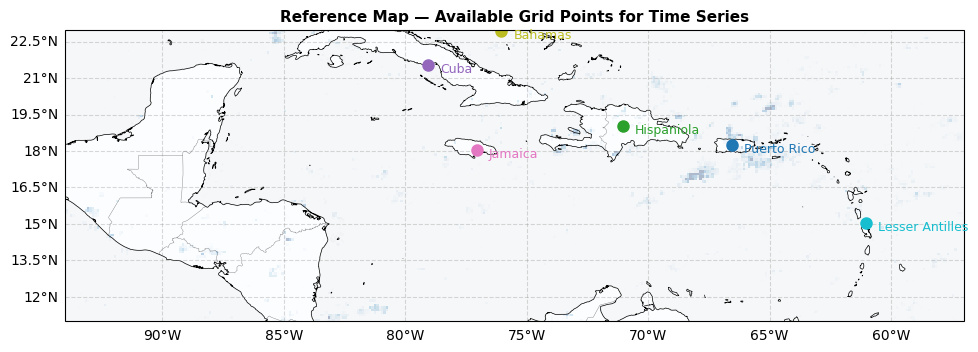

In [7]:
# ═══════════════════════════════════════════
# 7. Spaghetti Time Series at Selected Grid Points
# ═══════════════════════════════════════════
# Pick a latitude and longitude to see all 50 ensemble member time series

# First, let's see what geography we're dealing with
print("Map of the region with numbered grid points for reference:")
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Sample some island locations in the Caribbean
sample_points = {
    'Puerto Rico': (18.2, -66.5),
    'Hispaniola': (19.0, -71.0),
    'Cuba': (21.5, -79.0),
    'Jamaica': (18.0, -77.0),
    'Bahamas': (24.0, -76.0),
    'Lesser Antilles': (15.0, -61.0),
}

# Find nearest grid points
def find_nearest(lat, lon, lats, lons):
    """Find nearest grid index to given lat/lon."""
    lat_idx = np.argmin(np.abs(lats - lat))
    lon_idx = np.argmin(np.abs(lons - lon))
    return lat_idx, lon_idx

lats = ds.lat.values
lons = ds.lon.values

ax.pcolormesh(lons, lats, ds.prcp.isel(time=0, ens_n=0).values,
              cmap='Blues', vmin=0, vmax=10, alpha=0.3, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.add_feature(cfeature.OCEAN, color='lightgray', alpha=0.2)
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3, color='gray')
gl.top_labels = False; gl.right_labels = False
gl.xformatter = LongitudeFormatter(); gl.yformatter = LatitudeFormatter()

colors = plt.cm.tab10(np.linspace(0, 1, len(sample_points)))
for (name, (lat, lon)), color in zip(sample_points.items(), colors):
    lat_idx, lon_idx = find_nearest(lat, lon, lats, lons)
    actual_lat, actual_lon = lats[lat_idx], lons[lon_idx]
    ax.plot(actual_lon, actual_lat, 'o', color=color, markersize=8,
            transform=ccrs.PlateCarree())
    ax.text(actual_lon+0.5, actual_lat-0.3, name, fontsize=9, color=color,
            transform=ccrs.PlateCarree())

ax.set_title('Reference Map — Available Grid Points for Time Series', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ═══════════════════════════════════════════
# 8. Spaghetti Plot — Interactive Point Selector
# ═══════════════════════════════════════════
# Use the dropdown to pick a location and see all 50 member time series
# with ensemble mean ± 1 std dev highlighted

@widgets.interact(
    location=widgets.Dropdown(
        options={k: (v[0], v[1]) for k, v in sample_points.items()},
        value=sample_points['Puerto Rico'],
        description='Location:'
    ),
    ymax=widgets.FloatSlider(min=10, max=80, step=5, value=40,
                              description='Max mm/hr:', continuous_update=False)
)
def plot_spaghetti(location, ymax):
    target_lat, target_lon = location
    lat_idx = np.argmin(np.abs(lats - target_lat))
    lon_idx = np.argmin(np.abs(lons - target_lon))
    actual_lat = lats[lat_idx]
    actual_lon = lons[lon_idx]

    # Extract time series at this grid point for all members (ens_n, time)
    times = ds.time.values
    prcp_point = ds.prcp[:, :, lat_idx, lon_idx].values  # shape (ens_n, time)

    fig, ax = plt.subplots(figsize=(14, 5))

    # Plot each member as a thin line (spaghetti)
    for m in range(prcp_point.shape[0]):
        ax.plot(times, prcp_point[m], lw=0.5, alpha=0.4, color='steelblue')

    # Ensemble mean
    ens_mean = prcp_point.mean(axis=0)
    ens_std = prcp_point.std(axis=0)
    ax.plot(times, ens_mean, lw=2.5, color='red', label='Ensemble Mean')
    ax.fill_between(times, ens_mean - ens_std, ens_mean + ens_std,
                    alpha=0.2, color='red', label='Mean ± 1σ')

    ax.set_xlabel('Time (UTC)', fontsize=10)
    ax.set_ylabel('Precipitation (mm/hr)', fontsize=10)
    ax.set_title(f'Ensemble Time Series at ({actual_lat:.1f}°N, {actual_lon:.1f}°W)\n'
                 f'50 members — Spaghetti Plot with Mean ± 1σ',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(0, ymax)
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    # Summary stats
    print(f"📍 Location: {actual_lat:.2f}°N, {actual_lon:.2f}°E (nearest grid point)")
    print(f"   Max ensemble mean: {ens_mean.max():.1f} mm/hr")
    print(f"   Max ensemble std:  {ens_std.max():.1f} mm/hr")
    print(f"   Mean ensemble spread: {ens_std.mean():.2f} mm/hr")

interactive(children=(Dropdown(description='Location:', options={'Puerto Rico': (18.2, -66.5), 'Hispaniola': (…

Computing accumulated precipitation... (this may take a moment)


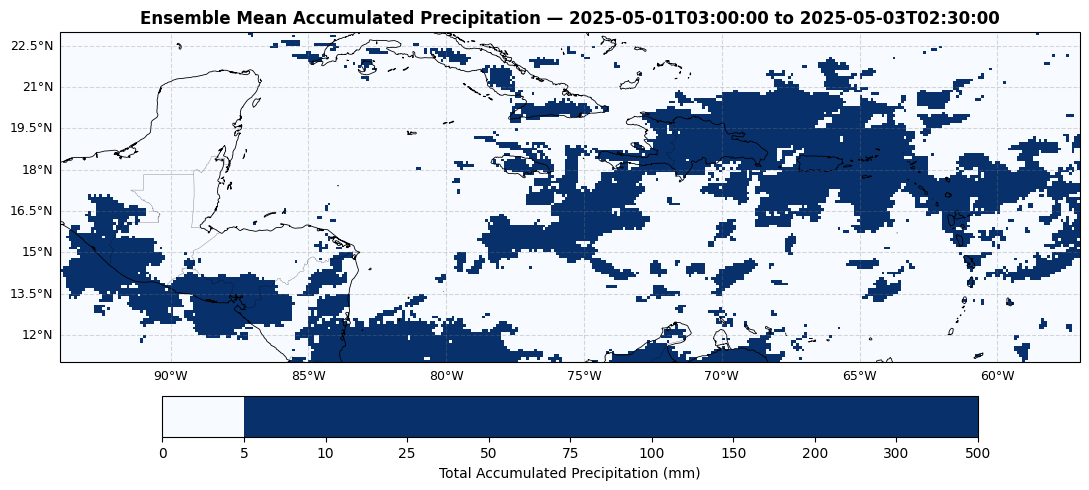

📊 Accumulation stats (ensemble mean):
   Max: 81.8 mm
   Mean across domain: 4.6 mm
   Total wet pixels (>1mm): 28391/44400


In [9]:
# ═══════════════════════════════════════════
# 9. Accumulated Precipitation — Ensemble Mean Total
# ═══════════════════════════════════════════
# Compute total accumulated precipitation from ensemble mean over the full period
# The data is half-hourly (mm/hr), so each timestep = 0.5 * mm/hr to get mm

print("Computing accumulated precipitation... (this may take a moment)")

# Compute ensemble mean, then accumulate along time (each timestep = 0.5 hr)
ens_mean = ds.prcp.mean(dim='ens_n')
# Accumulate: sum * 0.5 (hours to get mm)
accumulation = ens_mean.sum(dim='time') * 0.5

# Create a nice categorical colormap for accumulation
levels = [0, 5, 10, 25, 50, 75, 100, 150, 200, 300, 500]
norm = mcolors.BoundaryNorm(levels, 256)
cmap = plt.cm.get_cmap('Blues', len(levels)-1)

fig, ax = plt.subplots(figsize=(11, 7), subplot_kw={'projection': ccrs.PlateCarree()})

pcm = ax.pcolormesh(ds.lon.values, ds.lat.values, accumulation.values,
                    cmap=cmap, norm=norm, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.add_feature(cfeature.OCEAN, color='lightgray', alpha=0.3)
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3, color='gray')
gl.top_labels = False; gl.right_labels = False
gl.xformatter = LongitudeFormatter(); gl.yformatter = LatitudeFormatter()
gl.xlabel_style = {'size': 9}; gl.ylabel_style = {'size': 9}

cb = plt.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8,
                  ticks=levels)
cb.set_label('Total Accumulated Precipitation (mm)', fontsize=10)

t_range = f"{str(ds.time.values[0])[:19]} to {str(ds.time.values[-1])[:19]}"
ax.set_title(f'Ensemble Mean Accumulated Precipitation — {t_range}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"📊 Accumulation stats (ensemble mean):")
print(f"   Max: {accumulation.values.max():.1f} mm")
print(f"   Mean across domain: {accumulation.values.mean():.1f} mm")
print(f"   Total wet pixels (>1mm): {(accumulation.values > 1).sum()}/{accumulation.values.size}")

In [10]:
# ═══════════════════════════════════════════
# 10. Hovmöller Diagram (Time-Longitude Cross Section)
# ═══════════════════════════════════════════
# Shows ensemble mean precipitation as a function of time and longitude,
# averaged over a latitude band. Great for seeing propagating features!

@widgets.interact(
    lat_min=widgets.FloatSlider(min=lats.min(), max=lats.max()-2, step=1, value=14,
                                 description='Min Lat:', continuous_update=False),
    lat_max=widgets.FloatSlider(min=lats.min()+2, max=lats.max(), step=1, value=20,
                                 description='Max Lat:', continuous_update=False),
    vmax=widgets.FloatSlider(min=2, max=25, step=1, value=10,
                              description='Max mm/hr:', continuous_update=False)
)
def plot_hovmoller(lat_min, lat_max, vmax):
    # Average over latitude band and ensemble members
    lat_band = ds.prcp.mean(dim='ens_n').sel(lat=slice(lat_min, lat_max))
    hov = lat_band.mean(dim='lat')  # time x lon

    fig, ax = plt.subplots(figsize=(12, 6))

    pcm = ax.pcolormesh(ds.lon.values, ds.time.values, hov.values,
                        cmap='Blues', vmin=0, vmax=vmax)
    cb = plt.colorbar(pcm, ax=ax, orientation='vertical', shrink=0.85)
    cb.set_label('Precipitation (mm/hr)', fontsize=9)

    ax.set_xlabel('Longitude (°E)', fontsize=10)
    ax.set_ylabel('Time (UTC)', fontsize=10)
    ax.set_title(f'Hovmöller Diagram — Ensemble Mean Precipitation\n'
                 f'Latitude band: {lat_min}°N to {lat_max}°N ',
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.2)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

print("👆 Adjust latitude band with the sliders above.")

interactive(children=(FloatSlider(value=14.0, continuous_update=False, description='Min Lat:', max=20.94999885…

👆 Adjust latitude band with the sliders above.


In [11]:
# ═══════════════════════════════════════════
# 11. Animated Ensemble Mean Loop
# ═══════════════════════════════════════════
# Creates a looping animation of ensemble mean precipitation over time

from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Use a subset of frames for speed (every other frame = 1-hourly)
stride = 2
n_frames = len(ds.time) // stride
time_indices = range(0, len(ds.time), stride)

# Compute ensemble mean once (to avoid recomputation in animation loop)
print("Pre-computing ensemble means for animation...")
ens_mean_full = ds.prcp.mean(dim='ens_n').compute().values  # (time, lat, lon)
print(f"Done! Animating {n_frames} frames (hourly timesteps)...")

# Set up figure
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.add_feature(cfeature.OCEAN, color='lightgray', alpha=0.3)

pcm = ax.pcolormesh(ds.lon.values, ds.lat.values, ens_mean_full[0],
                    cmap='Blues', vmin=0, vmax=15, transform=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3, color='gray')
gl.top_labels = False; gl.right_labels = False
gl.xformatter = LongitudeFormatter(); gl.yformatter = LatitudeFormatter()
gl.xlabel_style = {'size': 8}; gl.ylabel_style = {'size': 8}

cb = plt.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8)
cb.set_label('Precipitation (mm/hr)', fontsize=9)

time_title = ax.set_title('', fontsize=11, fontweight='bold')

def animate(i):
    idx = time_indices[i]
    pcm.set_array(ens_mean_full[idx].ravel())
    t_str = str(ds.time.values[idx])[:19]
    time_title.set_text(f'Ensemble Mean Precipitation — {t_str} UTC')
    return pcm, time_title

ani = animation.FuncAnimation(fig, animate, frames=n_frames,
                              interval=300, blit=False)

# Display as HTML5 video
plt.close(fig)  # prevent duplicate display
HTML(ani.to_jshtml())

Pre-computing ensemble means for animation...
Done! Animating 48 frames (hourly timesteps)...


## 📋 Summary of Visualizations

| # | Visualization | What it shows |
|---|--------------|---------------|
| 1 | **Ensemble Mean & Spread** | Side-by-side maps of ensemble mean and standard deviation for a single timestep |
| 2 | **Interactive Explorer** | Widget-controlled map to explore any timestep, toggle between ensemble mean and individual members |
| 3 | **Percentile Maps** | P10, P50, P90 maps showing the distribution of ensemble members |
| 4 | **Probability of Exceedance** | Probability that precipitation exceeds a user-defined threshold |
| 5 | **Spaghetti Time Series** | All 50 members as time series at selected Caribbean locations, with ensemble mean ± 1σ |
| 6 | **Accumulated Precipitation** | Total accumulation over the full period from ensemble mean |
| 7 | **Hovmöller Diagram** | Time-longitude cross-section to track propagating precipitation features |
| 8 | **Animation** | Looping animation of ensemble mean over time |

### 🔍 Key things to look for:
- **High spread** areas indicate low confidence / high uncertainty in the estimate
- **Narrow spaghetti** bundles indicate high ensemble agreement
- **Probability maps** help identify areas with high confidence of significant precipitation
- **Hovmöller** reveals east/west propagation of weather systems
